# E5: perturbed SST response

Compute the time-mean response (perturbed minus unperturbed) of +2 and +4 K SST perturbation simulations

In [1]:
import xarray as xr
import numpy as np
import os
from dask import config as dask_config
from dask.diagnostics import ProgressBar
from cartopy import crs as ccrs
from matplotlib import pyplot as plt
import textwrap
import re
import matplotlib.ticker as mticker

from aimip_data_utils import (
    AIMIP_EXPERIMENT_SUBMISSIONS,
    AIMIP_P2K_EXPERIMENT_SUBMISSIONS,
    AIMIP_P4K_EXPERIMENT_SUBMISSIONS,
    EvaluationVariable,
    open_aimip_data,
    add_latlon_to_dlesym,
    regrid_dataset,
    transfer_attrs,
    convert_tdas_to_huss,
    compute_time_mean,
    load_gfdl_am4_from_cmip6_gcs,
    GFDL_CM4_AMIP_ZARR_TEMPLATE,
)

In [2]:
EVALUATION_DATES = ('1978-10-01', '2024-12-31')
LATITUDE_LIMITS = (-87.5, 87.5) # avoid regridding artifacts at the poles
OUTDIR = os.environ.get('AIMIP_FIGURES_DIR', './figures')
CACHE_DIR = os.environ.get('AIMIP_CACHE_DIR', './cached')
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
RESET_CACHE = False
RESTORE_CACHE = True

EVALUATION_PRESSURE_LEVELS = [
    85000.,
    50000.,
]

EVALUATION_VARIABLES = [
    EvaluationVariable(
        standard_name='surface_specific_humidity',
        long_name='specific humidity at 2 meters',
        short_name='huss',
        units='-'
    ),
    EvaluationVariable(
        standard_name='dew_point_temperature',
        long_name='dew point temperature at 2 meters',
        short_name='tdas',
        units='K'
    ),
    EvaluationVariable(
        standard_name='surface_air_pressure',
        long_name='air pressure at the surface',
        short_name='ps',
        units='Pa'
    ),
    EvaluationVariable(
        standard_name='precipitation_flux',
        long_name='precipitation_flux at the surface',
        short_name='pr',
        units='kg / s / m **2'
    ),
    EvaluationVariable(
        standard_name='air_temperature',
        long_name='air temperature',
        short_name='ta',
        units='K',
        standard_pressure_level_indexer={'plev': EVALUATION_PRESSURE_LEVELS},
    ),
    EvaluationVariable(
        standard_name='air_temperature',
        long_name='air temperature at 2 meters',
        short_name='tas',
        units='K',
    ),
    EvaluationVariable(
        standard_name='surface_temperature',
        long_name='surface temperature',
        short_name='ts',
        units='K',
    ),
    EvaluationVariable(
        standard_name='geopotential_height',
        long_name='geopotential height',
        short_name='zg',
        units='m',
        standard_pressure_level_indexer={'plev': [5e4]}, # 500 hPa height only
        drop_singleton_pressure_coord=True,
    ),
]

EVALUATION_VARIABLE_SUBSET = [eval_var for eval_var in EVALUATION_VARIABLES if eval_var.short_name not in ['tdas', 'ps']]
EVALUATION_VARIABLE_SUBSET_NAMES = [eval_var.short_name for eval_var in EVALUATION_VARIABLE_SUBSET]
GFDL_AM4_AMIP_P4K_ZARR_TEMPLATE = 'gs://cmip6/CMIP6/CFMIP/NOAA-GFDL/GFDL-CM4/amip-p4K/r1i1p1f1/Amon/{varname}/gr1/v20180701'

## How to run this notebook

This notebook runs in one of two modes, set by `RESET_CACHE` / `RESTORE_CACHE` in the cell above.

**Reproduce the manuscript figures from the bundled cache** — the default (`RESTORE_CACHE = True`, `RESET_CACHE = False`). No raw data is needed: run the setup cells above, then the **Restore minimal cache** cell, then the cells in the **Manuscript figures** section. You can skip the **Data loading & processing** section and the intermediate diagnostic cells — they read the full (~1.8 TB) raw dataset.

**Regenerate the cache from the raw dataset** (`RESET_CACHE = True`, `RESTORE_CACHE = False`). Download the full submissions (see the repo `README.md` → Data) and run every cell top to bottom; the minimal cache is rewritten from scratch.

## Data loading & processing

*Skip this section when using the bundled cache.* These cells read the full raw dataset and are only needed to regenerate the cache (`RESET_CACHE = True`).

In [3]:
monthly_data, missing_files = open_aimip_data(
    AIMIP_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    table='Amon',
)
print(missing_files)

ACE2.1-ERA5
surface_specific_humidity
../../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r1i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r2i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r3i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r4i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r4i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r5i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r5i1p1f1_gn_197810-202412.nc
dew_point_temperature
Not found: ../../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r1i1p1f1_gr_197810-202412.nc
Not found: ../../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r2i1p1f1_gr_197810-202412.nc
Not found: ../../local_data/Ai2/ACE2

In [4]:
for experiment_submission_name, dataset in monthly_data.items():
    print(f"Checking {experiment_submission_name} for huss/tdas.")
    monthly_data[experiment_submission_name] = convert_tdas_to_huss(dataset)

Checking ACE2.1-ERA5 for huss/tdas.
'huss' already present in dataset.
Checking ArchesWeather for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking ArchesWeatherGen for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking cBottle1.3 for huss/tdas.
'huss' already present in dataset.
Checking DLESyM for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking MD-1.5 v0.9 for huss/tdas.
'huss' already present in dataset.
Checking NeuralGCM for huss/tdas.
Converting 'tdas' to 'huss'.
Checking NeuralGCM-HRD for huss/tdas.
Converting 'tdas' to 'huss'.


In [5]:
monthly_data_p2k, missing_files_p2k = open_aimip_data(
    AIMIP_P2K_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    table='Amon',
)
print(missing_files_p2k)

ACE2.1-ERA5
surface_specific_humidity
../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r1i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p2k_r1i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r2i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p2k_r2i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r3i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p2k_r3i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r4i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p2k_r4i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r5i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p2k_r5i1p1f1_gn_197810-202412.nc
dew_point_temperature
Not found: ../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r1i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p2k_r1i1p1f1_gr_197810-202412.nc
Not found: ../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r2i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p2k_r2i1p1f1_

In [6]:
for experiment_submission_name, dataset in monthly_data_p2k.items():
    print(f"Checking {experiment_submission_name} for huss/tdas.")
    monthly_data_p2k[experiment_submission_name] = convert_tdas_to_huss(dataset)

Checking ACE2.1-ERA5 for huss/tdas.
'huss' already present in dataset.
Checking ArchesWeather for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking ArchesWeatherGen for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking cBottle1.3 for huss/tdas.
'huss' already present in dataset.
Checking DLESyM for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking MD-1.5 v0.9 for huss/tdas.
'huss' already present in dataset.
Checking NeuralGCM for huss/tdas.
Converting 'tdas' to 'huss'.
Checking NeuralGCM-HRD for huss/tdas.
Converting 'tdas' to 'huss'.


In [7]:
monthly_data_p4k, missing_files_p4k = open_aimip_data(
    AIMIP_P4K_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    table='Amon',
)
print(missing_files_p4k)

ACE2.1-ERA5
surface_specific_humidity
../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r1i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p4k_r1i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r2i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p4k_r2i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r3i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p4k_r3i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r4i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p4k_r4i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r5i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p4k_r5i1p1f1_gn_197810-202412.nc
dew_point_temperature
Not found: ../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r1i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p4k_r1i1p1f1_gr_197810-202412.nc
Not found: ../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r2i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p4k_r2i1p1f1_

In [8]:
for experiment_submission_name, dataset in monthly_data_p4k.items():
    print(f"Checking {experiment_submission_name} for huss/tdas.")
    monthly_data_p4k[experiment_submission_name] = convert_tdas_to_huss(dataset)

Checking ACE2.1-ERA5 for huss/tdas.
'huss' already present in dataset.
Checking ArchesWeather for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking ArchesWeatherGen for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking cBottle1.3 for huss/tdas.
'huss' already present in dataset.
Checking DLESyM for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking MD-1.5 v0.9 for huss/tdas.
'huss' already present in dataset.
Checking NeuralGCM for huss/tdas.
Converting 'tdas' to 'huss'.
Checking NeuralGCM-HRD for huss/tdas.
Converting 'tdas' to 'huss'.


In [9]:
perturbation_submissions = sorted(list(
    set(monthly_data.keys()) & set(monthly_data_p2k.keys()) & set(monthly_data_p4k.keys())
), key=lambda x: x.lower())
perturbed_sst_response = {}
for k in perturbation_submissions:
    print(k)
    dataset_eval_vars = [var for var in monthly_data[k].data_vars if var in EVALUATION_VARIABLE_SUBSET_NAMES]
    with xr.set_options(keep_attrs=True):
        perturbed_sst_response[k] = xr.concat(
            [
                (monthly_data_p2k[k] - monthly_data[k])[dataset_eval_vars].expand_dims(
                    {
                        'perturbation': ['+2K-SST'],
                    }
                ),
                (monthly_data_p4k[k] - monthly_data[k])[dataset_eval_vars].expand_dims(
                    {
                        'perturbation': ['+4K-SST'],
                    }
                ),
            ],
            dim='perturbation'
        ) 

ACE2.1-ERA5
ArchesWeather
ArchesWeatherGen
cBottle1.3
DLESyM
MD-1.5 v0.9
NeuralGCM
NeuralGCM-HRD


In [10]:
# add coordinates to DLESyM
perturbed_sst_response['DLESyM'] = add_latlon_to_dlesym(perturbed_sst_response['DLESyM'])
perturbed_sst_response['DLESyM'] = perturbed_sst_response['DLESyM'].set_coords(['i'])

In [11]:
perturbed_sst_response_time_mean = {
    k: compute_time_mean(v, start=EVALUATION_DATES[0], end=EVALUATION_DATES[1])
    for k, v in perturbed_sst_response.items()
}

In [12]:
perturbed_sst_response_time_mean.keys()

dict_keys(['ACE2.1-ERA5', 'ArchesWeather', 'ArchesWeatherGen', 'cBottle1.3', 'DLESyM', 'MD-1.5 v0.9', 'NeuralGCM', 'NeuralGCM-HRD'])

In [13]:
with ProgressBar():
    perturbed_sst_response_time_mean = {
        k: v.compute() for k, v in perturbed_sst_response_time_mean.items()
    }

[########################################] | 100% Completed | 163.06 s
[########################################] | 100% Completed | 111.41 s
[########################################] | 100% Completed | 114.37 s
[########################################] | 100% Completed | 175.52 s
[########################################] | 100% Completed | 25.11 s
[########################################] | 100% Completed | 179.49 s
[########################################] | 100% Completed | 61.90 s
[########################################] | 100% Completed | 97.27 s


In [14]:
other_variables = ['lat', 'lat_bnds', 'lon', 'lon_bnds']
gfdl_cm4_amip, missing_paths_gfdl_cm4 = load_gfdl_am4_from_cmip6_gcs(GFDL_CM4_AMIP_ZARR_TEMPLATE, EVALUATION_VARIABLE_SUBSET, other_variables)
gfdl_am4_amip_p4k, missing_paths_gfdl_am4_p4k = load_gfdl_am4_from_cmip6_gcs(GFDL_AM4_AMIP_P4K_ZARR_TEMPLATE, EVALUATION_VARIABLE_SUBSET, other_variables)
# CM4 AMIP and CM4 amip-p4K both start in 1979; assign_coords to ensure identical time coordinates
gfdl_am4_amip_p4k = gfdl_am4_amip_p4k.assign_coords({'time': gfdl_cm4_amip.time})

with xr.set_options(keep_attrs=True):
    gfdl_amip4_perturbed_sst_response = (gfdl_am4_amip_p4k - gfdl_cm4_amip).expand_dims(
        {
            'perturbation': ['+4K-SST'],
        }
    ).drop_vars(['lat_bnds', 'lon_bnds'])

gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/huss/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/pr/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/ta/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/tas/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/ts/gr1/v20180701
gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/zg/gr1/v20180701
gs://cmip6/CMIP6/CFMIP/NOAA-GFDL/GFDL-CM4/amip-p4K/r1i1p1f1/Amon/huss/gr1/v20180701
gs://cmip6/CMIP6/CFMIP/NOAA-GFDL/GFDL-CM4/amip-p4K/r1i1p1f1/Amon/pr/gr1/v20180701
gs://cmip6/CMIP6/CFMIP/NOAA-GFDL/GFDL-CM4/amip-p4K/r1i1p1f1/Amon/ta/gr1/v20180701
gs://cmip6/CMIP6/CFMIP/NOAA-GFDL/GFDL-CM4/amip-p4K/r1i1p1f1/Amon/tas/gr1/v20180701
gs://cmip6/CMIP6/CFMIP/NOAA-GFDL/GFDL-CM4/amip-p4K/r1i1p1f1/Amon/ts/gr1/v20180701
gs://cmip6/CMIP6/CFMIP/NOAA-GFDL/GFDL-CM4/amip-p4K/r1i1p1f1/Amon/zg/gr1/v20180701


In [15]:
with ProgressBar():
    gfdl_amip4_perturbed_sst_response_time_mean = compute_time_mean(
        gfdl_amip4_perturbed_sst_response,
        start=EVALUATION_DATES[0],
        end=EVALUATION_DATES[1],
    ).compute()

[########################################] | 100% Completed | 14.04 s


In [16]:
# split plev var into variables
for experiment_submission, ds in perturbed_sst_response_time_mean.items():
    print(experiment_submission)
    if len(ds.coords['plev']) == 2:
        ds['ta_850'] = ds.ta.sel(plev=8.5e4)
        ds['ta_500'] = ds.ta.sel(plev=5.0e4)
    else:
        ds['ta_850'] = ds.ta.sel(plev=8.5e4)
    ds = ds.drop_vars(['ta', 'plev'])
    perturbed_sst_response_time_mean[experiment_submission] = ds

ACE2.1-ERA5
ArchesWeather
ArchesWeatherGen
cBottle1.3
DLESyM
MD-1.5 v0.9
NeuralGCM
NeuralGCM-HRD


In [17]:
# also for GFDL CM4
gfdl_amip4_perturbed_sst_response_time_mean['ta_850'] = gfdl_amip4_perturbed_sst_response_time_mean.ta.sel(plev=8.5e4, method='nearest')
gfdl_amip4_perturbed_sst_response_time_mean['ta_500'] = gfdl_amip4_perturbed_sst_response_time_mean.ta.sel(plev=5.0e4, method='nearest')
gfdl_amip4_perturbed_sst_response_time_mean = gfdl_amip4_perturbed_sst_response_time_mean.drop_vars(['ta', 'plev'])

In [18]:
regridded_1deg_perturbed_sst_response_time_means = []
experiment_submissions_1deg = list(perturbed_sst_response_time_mean.keys())
experiment_submissions_1deg.remove('NeuralGCM') # don't evaluate 2.8 deg at 1 deg
for experiment_submission_name in experiment_submissions_1deg:
    print(experiment_submission_name)
    if experiment_submission_name not in ['cBottle1.3', 'DLESyM']:
        regridder_kwargs = dict(method='conservative')
        src_dataset_bnds = monthly_data[experiment_submission_name][['lat_bnds', 'lon_bnds']]
        src_dataset_bnds = src_dataset_bnds if "time" not in src_dataset_bnds.coords else src_dataset_bnds.isel(time=0).drop_vars('time')
        src_dataset = xr.merge(
            [
                perturbed_sst_response_time_mean[experiment_submission_name],
                src_dataset_bnds
            ]
        )
    else: 
        # for cBottle HEALPix grid, need to use nearest-neighbor unstructured interpolation
        regridder_kwargs = dict(locstream_in=True, method='nearest_s2d')
        src_dataset = perturbed_sst_response_time_mean[experiment_submission_name]
    # destination grid is GFDL CM4 1 deg lat / 1.25 deg lon grid
    destination_grid = (
        gfdl_cm4_amip
        .sel(lat=slice(*LATITUDE_LIMITS))
        [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
    )

    regridded_1deg_perturbed_sst_response_time_mean = regrid_dataset(
        src_dataset,
        destination_grid,
        sample_dims=['realization', 'perturbation'],
        **regridder_kwargs
    )
    regridded_1deg_perturbed_sst_response_time_means.append(
        regridded_1deg_perturbed_sst_response_time_mean.expand_dims(
            {
                'experiment_submission': [experiment_submission_name]
            }
        )
    )
regridded_1deg_perturbed_sst_response_time_means = xr.concat(regridded_1deg_perturbed_sst_response_time_means, dim='experiment_submission', join='outer', combine_attrs='override')

ACE2.1-ERA5


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


ArchesWeather


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


ArchesWeatherGen


...

/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


DLESyM
MD-1.5 v0.9


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


NeuralGCM-HRD


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/br

In [19]:
with xr.set_options(keep_attrs=True):
    combined_1deg_perturbed_sst_response_time_means = xr.concat(
        [
            regridded_1deg_perturbed_sst_response_time_means.mean('realization'),
            (
                gfdl_amip4_perturbed_sst_response_time_mean
                .sel(lat=slice(*LATITUDE_LIMITS))
                .expand_dims({'experiment_submission': ['GFDL-CM4']})
            ),
        ],
        dim='experiment_submission',
        join='outer',
    )

In [20]:
regridded_2p8deg_perturbed_sst_response_time_means = []
experiment_submissions_2p8deg = list(perturbed_sst_response_time_mean.keys())
experiment_submissions_2p8deg.remove('NeuralGCM-HRD') # don't evaluate 1deg at 2.8 deg
for experiment_submission_name in experiment_submissions_2p8deg:
    print(experiment_submission_name)
    if experiment_submission_name not in ['cBottle1.3', 'DLESyM']:
        regridder_kwargs = dict(method='conservative')
        src_dataset_bnds = monthly_data[experiment_submission_name][['lat_bnds', 'lon_bnds']]
        src_dataset_bnds = src_dataset_bnds if "time" not in src_dataset_bnds.coords else src_dataset_bnds.isel(time=0).drop_vars('time')
        src_dataset = xr.merge(
            [
                perturbed_sst_response_time_mean[experiment_submission_name],
                src_dataset_bnds
            ]
        )
    else: 
        # for cBottle HEALPix grid, need to use nearest-neighbor unstructured interpolation
        regridder_kwargs = dict(locstream_in=True, method='nearest_s2d')
        src_dataset = perturbed_sst_response_time_mean[experiment_submission_name]
    # destination grid is 2p8deg NeuralGCM
    destination_grid = (
        monthly_data['NeuralGCM']
        .isel(realization=0)
        .sel(lat=slice(*LATITUDE_LIMITS))
        [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
    )
    regridded_2p8deg_perturbed_sst_response_time_mean = regrid_dataset(
        src_dataset,
        destination_grid,
        sample_dims=['realization', 'perturbation'],
        **regridder_kwargs
    )
    regridded_2p8deg_perturbed_sst_response_time_means.append(
        regridded_2p8deg_perturbed_sst_response_time_mean.expand_dims(
            {
                'experiment_submission': [experiment_submission_name]
            }
        )
    )
regridded_2p8deg_perturbed_sst_response_time_means = xr.concat(regridded_2p8deg_perturbed_sst_response_time_means, dim='experiment_submission', join='outer', combine_attrs='override')

ACE2.1-ERA5


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


ArchesWeather


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


ArchesWeatherGen


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/frontend.py:76: UserWarning: Variables {'crs'} not found in object but are referred to in the CF attributes.
  lon = ds.cf['longitude']
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/frontend.py:77: UserWarning: Variables {'crs'} not found in object but are referred to in the CF attributes.
  lat = ds.cf['latitude']
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.1

cBottle1.3
DLESyM
MD-1.5 v0.9


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


NeuralGCM


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/br

In [21]:
# regrid GFDL CM4 to 2.8 deg NeuralGCM grid
destination_grid = (
    monthly_data['NeuralGCM']
    .isel(realization=0)
    .sel(lat=slice(*LATITUDE_LIMITS))
    [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
)
src_dataset_bnds = gfdl_cm4_amip[['lat_bnds', 'lon_bnds']] # since these are data vars not coords they can't come from diff dataset
src_dataset = xr.merge(
    [
        gfdl_amip4_perturbed_sst_response_time_mean,
        src_dataset_bnds
    ]
)
regridded_2p8deg_perturbed_sst_response_time_mean_gfdl_cm4 = regrid_dataset(
    src_dataset,
    destination_grid,
    sample_dims=['perturbation'],
    method='conservative',
)

In [22]:
with xr.set_options(keep_attrs=True):
    combined_2p8deg_perturbed_sst_response_time_means = xr.concat(
        [
            regridded_2p8deg_perturbed_sst_response_time_means.mean('realization'),
            (
                regridded_2p8deg_perturbed_sst_response_time_mean_gfdl_cm4
                .expand_dims({'experiment_submission': ['GFDL-CM4']})
            ),
        ],
        dim='experiment_submission',
        join='outer',
    )

In [23]:
if RESET_CACHE:
    path_1deg = os.path.join(CACHE_DIR, 'combined_1deg_perturbed_sst_response_time_means.nc')
    path_2p8deg = os.path.join(CACHE_DIR, 'combined_2p8deg_perturbed_sst_response_time_means.nc')
    try:
        os.remove(path_1deg)
        os.remove(path_2p8deg)
    except FileNotFoundError:
        print("Nothing deleted from cache.")
    combined_1deg_perturbed_sst_response_time_means[['tas', 'pr']].to_netcdf(path_1deg)
    combined_2p8deg_perturbed_sst_response_time_means[['tas', 'pr']].to_netcdf(path_2p8deg)
    print("Cache updated.")

Cache updated.


## Restore minimal cache

*Start here when using the bundled cache* (`RESTORE_CACHE = True`). This loads the reduced, plot-ready inputs for the manuscript figures. The cells between here and **Manuscript figures** produce supplementary diagnostics; some require the full dataset, so skip them in cache mode.

In [24]:
if RESTORE_CACHE:
    print("Cache restored.")
    path_1deg = os.path.join(CACHE_DIR, 'combined_1deg_perturbed_sst_response_time_means.nc')
    path_2p8deg = os.path.join(CACHE_DIR, 'combined_2p8deg_perturbed_sst_response_time_means.nc')
    combined_1deg_perturbed_sst_response_time_means = xr.open_dataset(path_1deg)
    combined_2p8deg_perturbed_sst_response_time_means = xr.open_dataset(path_2p8deg)

## Supplementary diagnostics

*Skip this section when using the bundled cache.* These non-manuscript diagnostics require the full dataset (they use variables/fields not kept in the minimal cache).

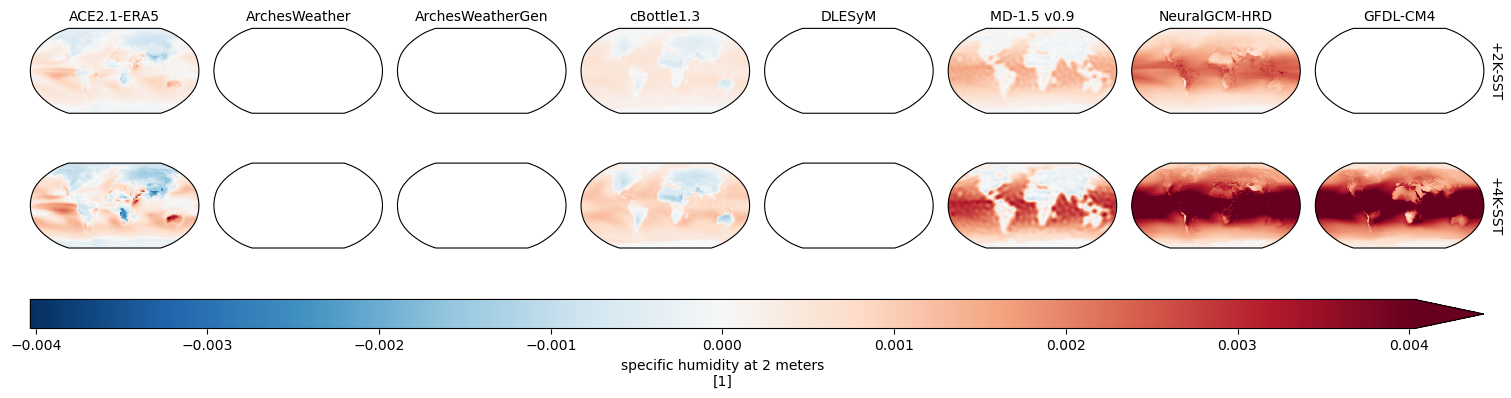

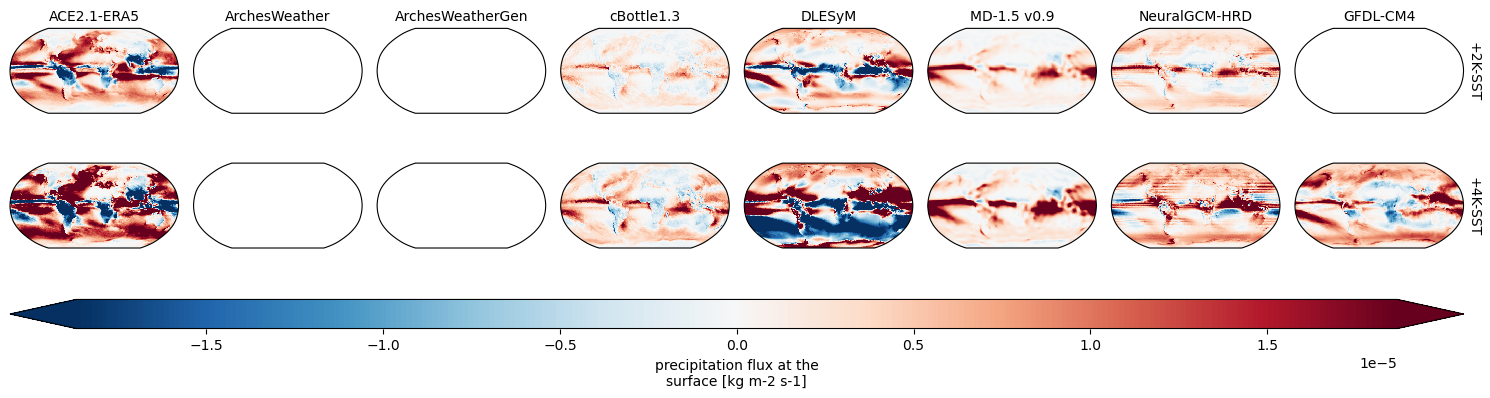

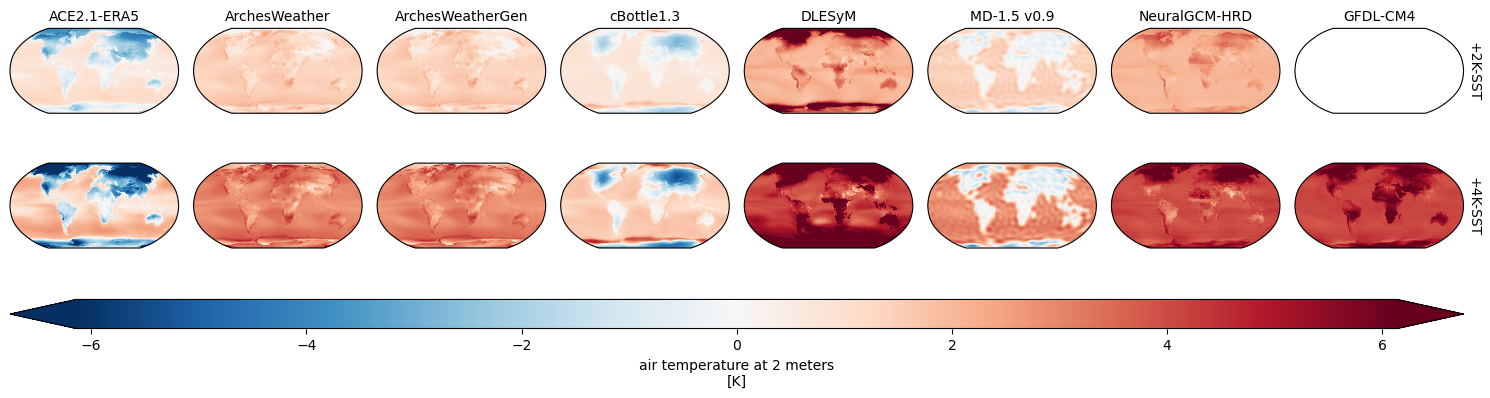

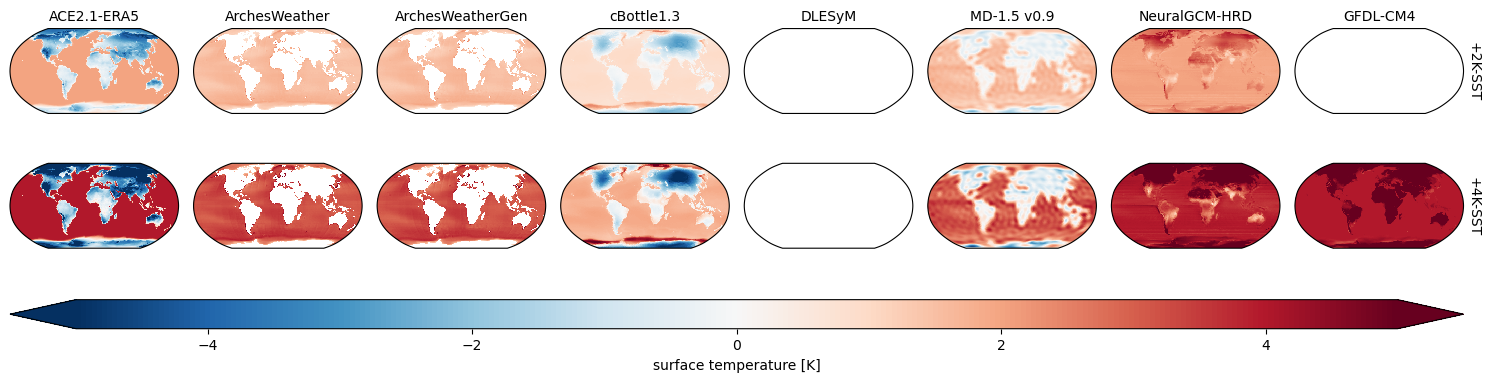

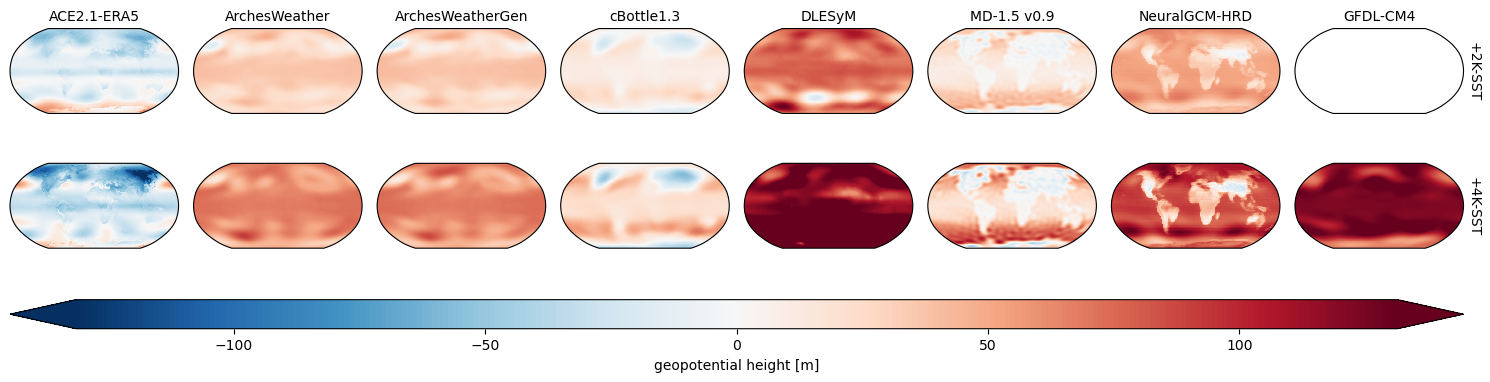

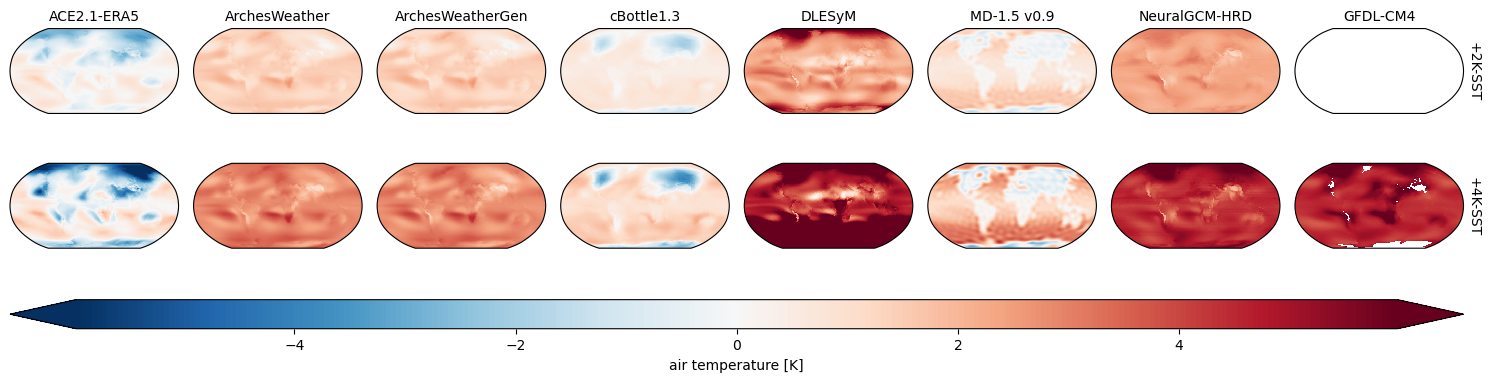

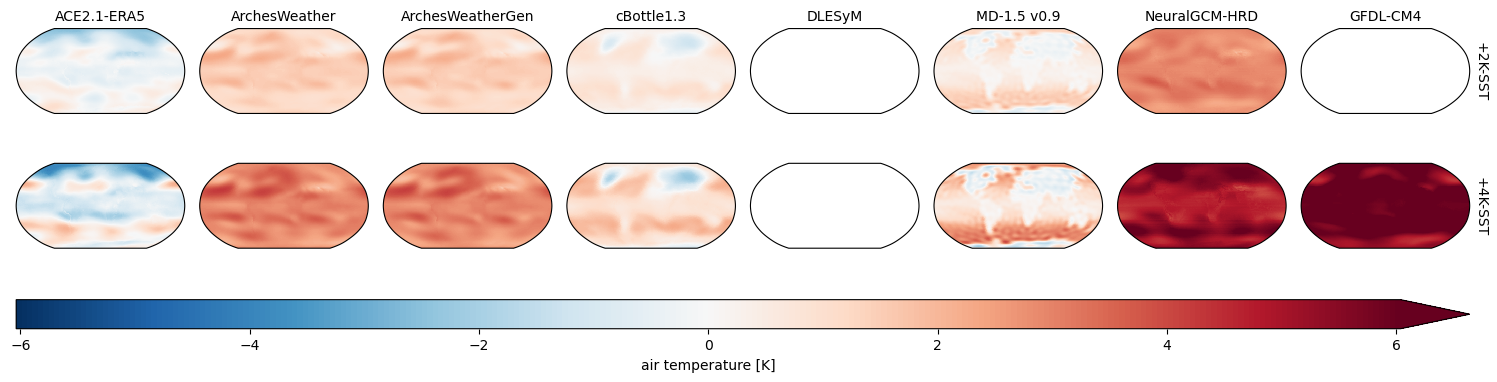

In [25]:
for var in combined_1deg_perturbed_sst_response_time_means.data_vars:
    plottable = combined_1deg_perturbed_sst_response_time_means[var]
    if "plev" in plottable.dims:
        plottable = plottable.isel(plev=0)
    vmax = plottable.quantile(0.95)
    fg = plottable.plot(
        figsize=(15, 4),
        subplot_kws=dict(projection=ccrs.Robinson()),
        transform=ccrs.PlateCarree(),
        col='experiment_submission', row='perturbation',
        vmin=-vmax, vmax=vmax, cmap='RdBu_r',
        cbar_kwargs=dict(orientation='horizontal', aspect=50),
    )
    fg.set_titles('{value}')
    fg.fig.patch.set_alpha(0.0)
    fg.fig.savefig(os.path.join(OUTDIR, f'perturbed_sst_response_1deg_map_{var}.png'), bbox_inches='tight')

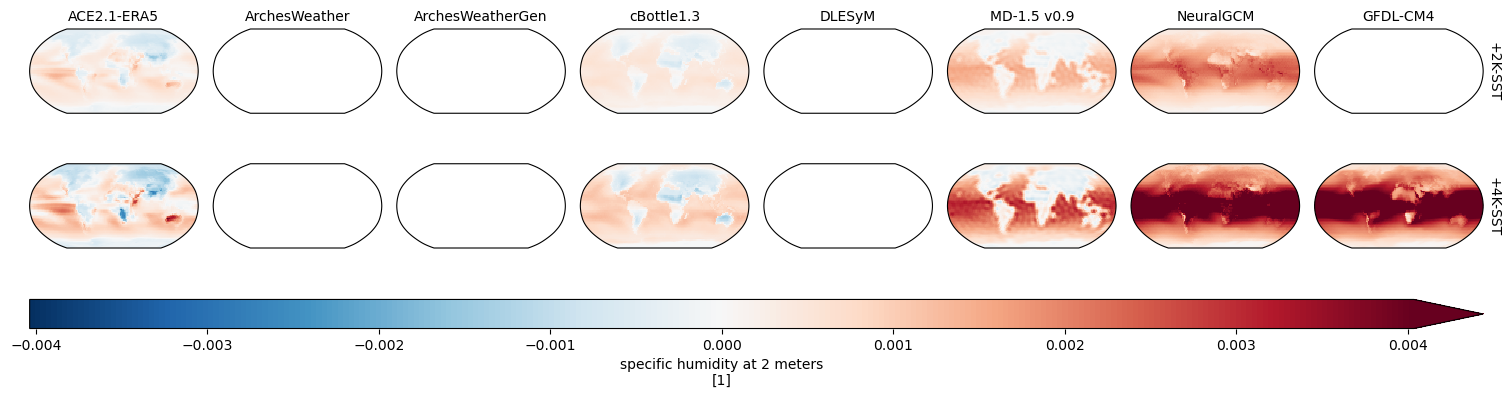

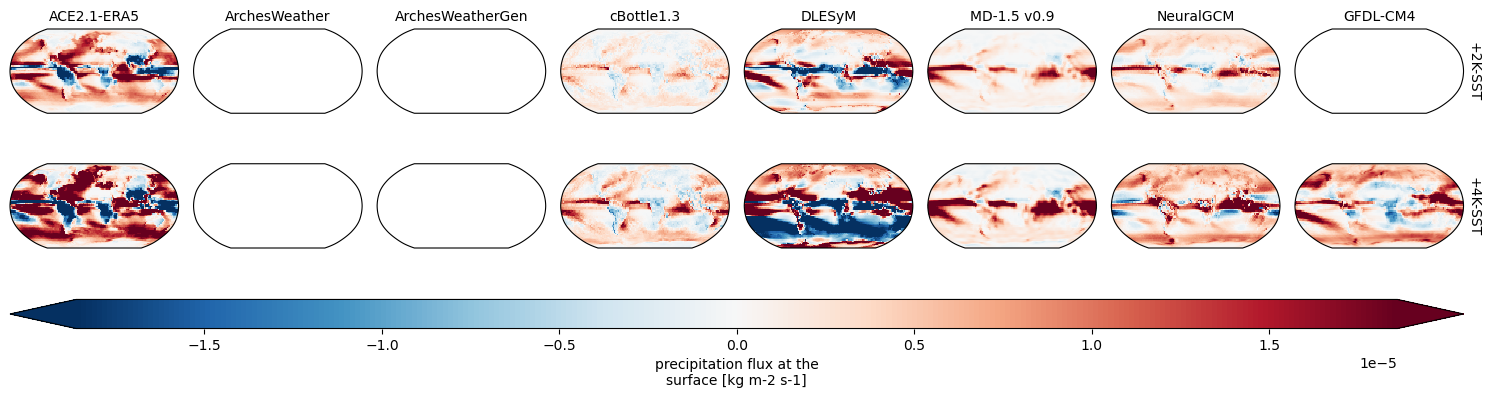

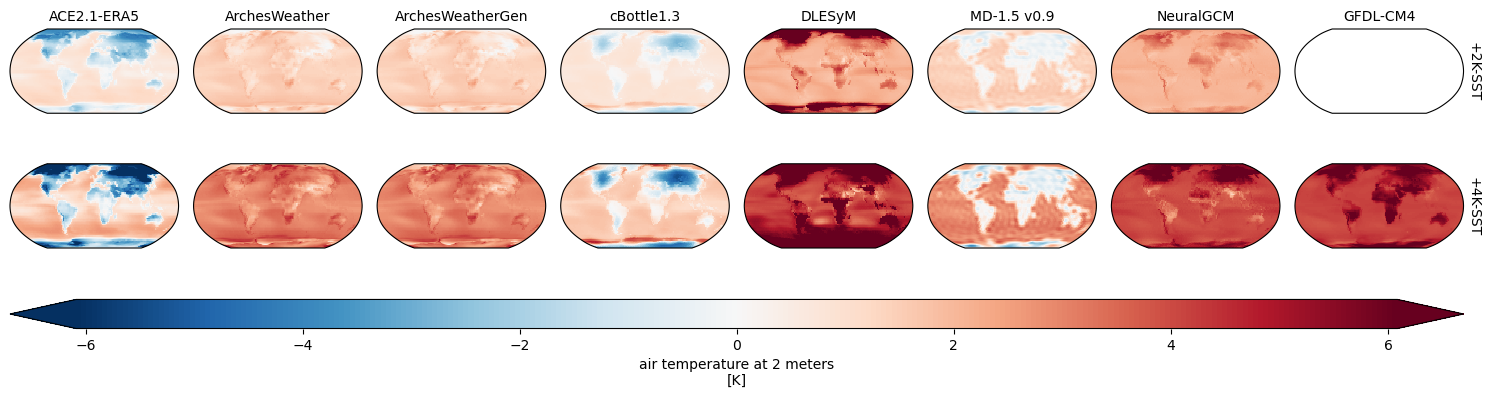

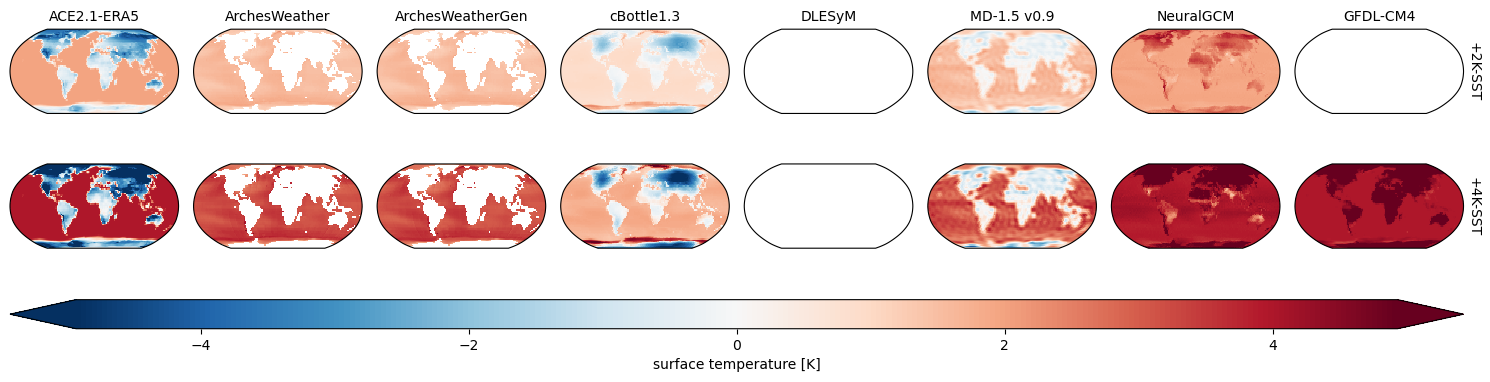

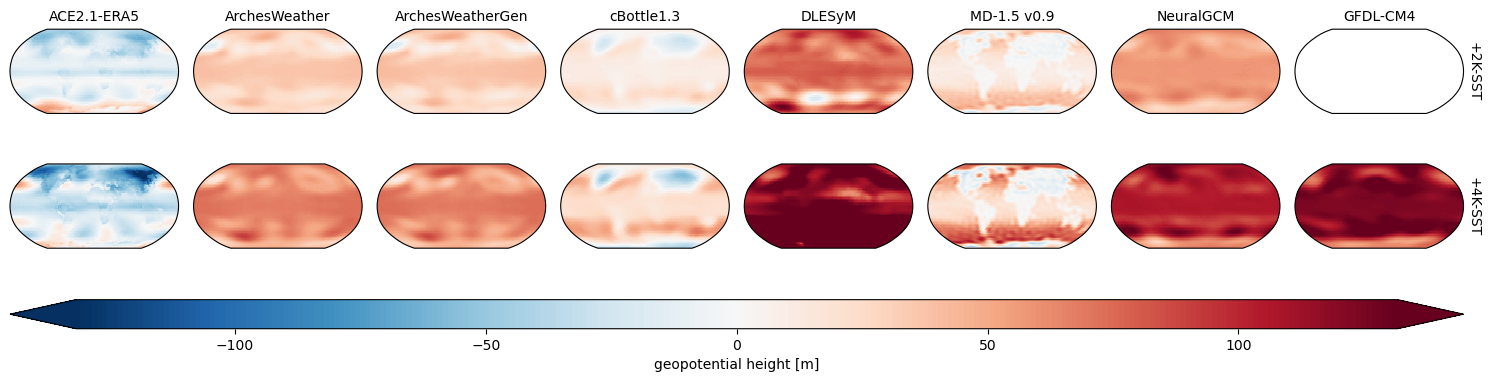

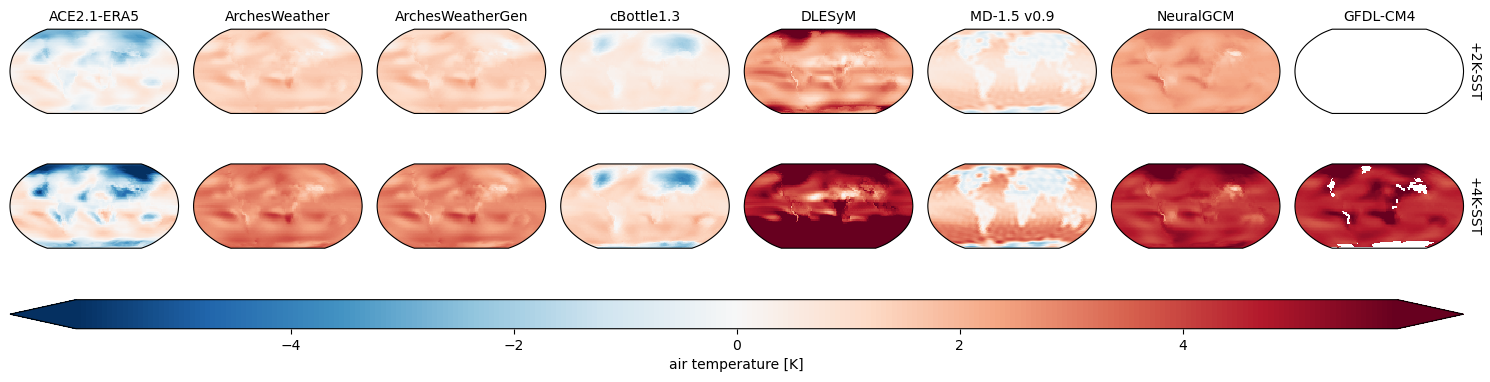

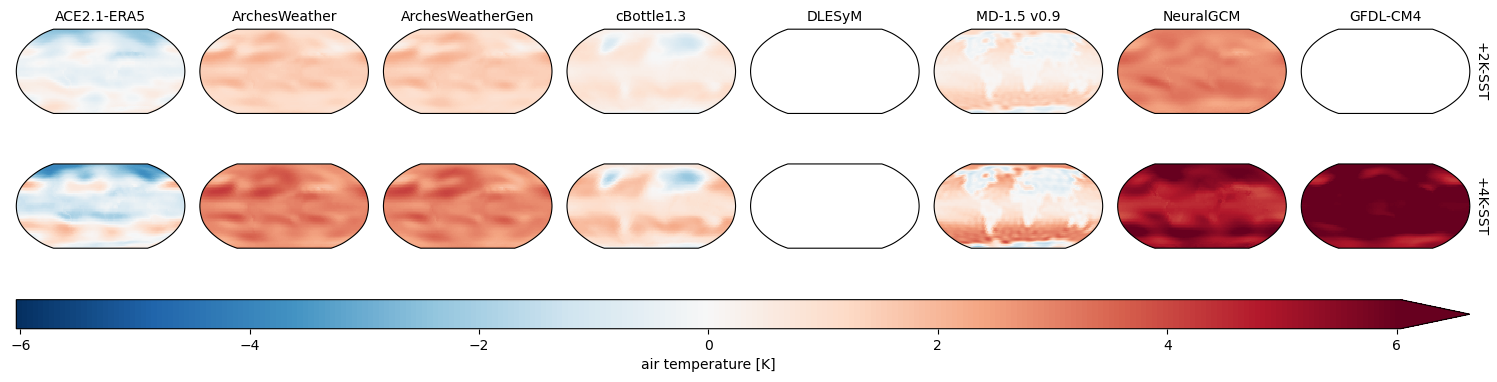

In [26]:
for var in combined_2p8deg_perturbed_sst_response_time_means.data_vars:
    plottable = combined_2p8deg_perturbed_sst_response_time_means[var]
    if "plev" in plottable.dims:
        plottable = plottable.isel(plev=0)
    vmax = plottable.quantile(0.95)
    fg = plottable.plot(
        figsize=(15, 4),
        subplot_kws=dict(projection=ccrs.Robinson()),
        transform=ccrs.PlateCarree(),
        col='experiment_submission', row='perturbation',
        vmin=-vmax, vmax=vmax, cmap='RdBu_r',
        cbar_kwargs=dict(orientation='horizontal', aspect=50),
    )
    fg.set_titles('{value}')
    fg.fig.patch.set_alpha(0.0)
    fg.fig.savefig(os.path.join(OUTDIR, f'perturbed_sst_response_2p8deg_map_{var}.png'), bbox_inches='tight')

## Manuscript Figures

In [27]:
MANUSCRIPT_DIR = os.path.join(OUTDIR, 'manuscript_figures')
os.makedirs(MANUSCRIPT_DIR, exist_ok=True)

MANUSCRIPT_DPI = 300
MANUSCRIPT_FORMAT = 'eps'
GMD_SINGLE_COL_IN = 84 / 25.4
GMD_DOUBLE_COL_IN = 174 / 25.4
GMD_MAX_HEIGHT_IN = 170 / 25.4  # leave room for caption
LABEL_FS = 7

VAR_SCALE = {'pr': 86400.}
VAR_DISPLAY_UNITS = {'pr': 'mm day$^{-1}$'}

def ms_savefig(fig, name):
    path = os.path.join(MANUSCRIPT_DIR, f'{name}.{MANUSCRIPT_FORMAT}')
    fig.savefig(path, dpi=MANUSCRIPT_DPI, format=MANUSCRIPT_FORMAT)
    fig.savefig(os.path.join(MANUSCRIPT_DIR, f'{name}.png'), dpi=MANUSCRIPT_DPI, format='png')
    print(f'Saved {path}')

In [28]:
def _wrap_row_label(s, min_part=3, max_lines=2):
    """Split at CamelCase boundaries for rotated row labels; cap at max_lines."""
    parts = re.split(r'(?<=[a-z])(?=[A-Z])', s)
    # Merge any part shorter than min_part with its neighbour
    merged = [parts[0]]
    for p in parts[1:]:
        if len(merged[-1]) < min_part or len(p) < min_part:
            merged[-1] += p
        else:
            merged.append(p)
    # If still too many lines, fold down to max_lines by joining at the most
    # balanced split point (minimises the length difference between two halves)
    while len(merged) > max_lines:
        best_i, best_balance = 0, float('inf')
        for i in range(len(merged) - 1):
            joined = merged[i] + merged[i + 1]
            # Balance = difference in lengths of the two groups that would result
            left_len  = sum(len(m) for m in merged[:i]) + len(joined)
            right_len = sum(len(m) for m in merged[i + 2:])
            balance = abs(left_len - right_len)
            if balance < best_balance:
                best_balance, best_i = balance, i
        merged = merged[:best_i] + [merged[best_i] + merged[best_i + 1]] + merged[best_i + 2:]
    return '\n'.join(merged)


def plot_perturbation_response_map(ds, vars_to_plot, save_name):
    perturbations = ['+2K-SST', '+4K-SST']
    pert_labels = {'+2K-SST': '+2K', '+4K-SST': '+4K'}
    exp_names = list(ds.experiment_submission.values)
    n_exp = len(exp_names)

    cols = [(var, pert) for var in vars_to_plot for pert in perturbations]
    n_cols, n_rows = len(cols), n_exp

    vlims = {
        var: float(
            abs(ds[var] * VAR_SCALE.get(var, 1.0)).quantile(0.95)
        )
        for var in vars_to_plot
    }

    map_h = (GMD_DOUBLE_COL_IN / n_cols) / 1.9
    fig_height = min(n_rows * map_h * 1.15 + 1.0, GMD_MAX_HEIGHT_IN)
    fig = plt.figure(figsize=(GMD_DOUBLE_COL_IN, fig_height))
    gs = fig.add_gridspec(nrows=n_rows, ncols=n_cols, hspace=0.08, wspace=0.05)
    fig.subplots_adjust(top=0.88, left=0.16)

    ims_by_var = {}
    axes_by_var = {var: [] for var in vars_to_plot}
    top_row_axes = {}
    col0_axes = {}

    panel_letter = ord('a')
    for row, exp in enumerate(exp_names):
        for col, (var, pert) in enumerate(cols):
            scale = VAR_SCALE.get(var, 1.0)
            ax = fig.add_subplot(gs[row, col], projection=ccrs.Robinson())
            axes_by_var[var].append(ax)
            if row == 0:
                top_row_axes[col] = ax
            if col == 0:
                col0_axes[row] = ax

            data_sel = ds[var].sel(experiment_submission=exp, perturbation=pert, drop=True) * scale

            if bool(np.isnan(data_sel.values).all()):
                ax.set_global()
            else:
                im = data_sel.plot(
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    cmap='RdBu_r',
                    vmin=-vlims[var], vmax=vlims[var],
                    add_colorbar=False,
                    add_labels=False, rasterized=True,
                )
                ims_by_var[var] = im
            ax.set_title('')
            ax.coastlines(color='gray', linewidth=0.5)

            if row == 0:
                letter = chr(panel_letter)
                panel_letter += 1
                ax.set_title(f'({letter}) {pert_labels[pert]}', fontsize=LABEL_FS, pad=3)

    # Colorbars
    for var in vars_to_plot:
        if var not in ims_by_var:
            continue
        units = VAR_DISPLAY_UNITS.get(var, ds[var].attrs.get('units', ''))
        long_name = ds[var].attrs.get('long_name', var).replace('_', ' ').lower()
        cbar = fig.colorbar(
            ims_by_var[var],
            ax=axes_by_var[var],
            orientation='horizontal',
            fraction=0.015, pad=0.06, aspect=25,
            extend='both',
        )
        cbar.set_label(f'{long_name} [{units}]', size=LABEL_FS)
        cbar.ax.tick_params(labelsize=LABEL_FS - 1)
        cbar.ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))

    fig.canvas.draw()

    # Row labels: CamelCase line-breaking capped at 2 lines
    for row, exp in enumerate(exp_names):
        col0_axes[row].text(
            -0.12, 0.5, _wrap_row_label(exp),
            transform=col0_axes[row].transAxes,
            rotation=90, va='center', ha='center',
            fontsize=LABEL_FS, clip_on=False, multialignment='center',
        )

    # Variable group headers — offset raised to clear the panel titles
    for vi, var in enumerate(vars_to_plot):
        pos_l = top_row_axes[vi * 2].get_position()
        pos_r = top_row_axes[vi * 2 + 1].get_position()
        x_center = (pos_l.x0 + pos_r.x1) / 2
        long_name = ds[var].attrs.get('long_name', var).replace('_', ' ').lower()
        fig.text(x_center, pos_l.y1 + 0.04, long_name,
                 ha='center', va='bottom', fontsize=LABEL_FS)

    fig.patch.set_alpha(0.0)
    ms_savefig(fig, save_name)
    plt.show()

Saved ./figures/manuscript_figures/perturbation_response_map_tas_pr.eps


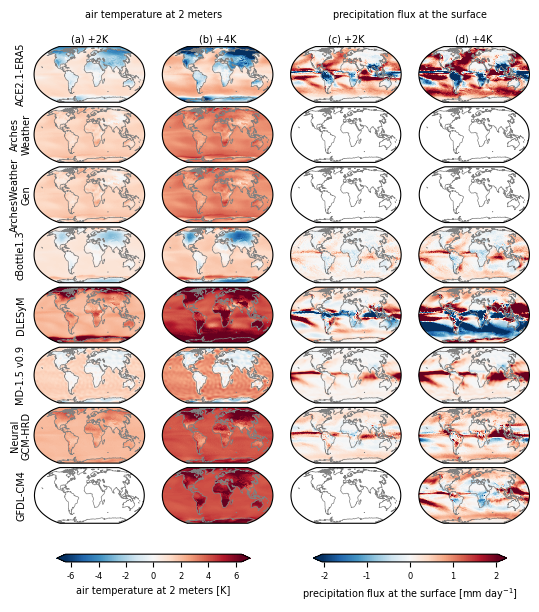

In [29]:
plot_perturbation_response_map(
    combined_1deg_perturbed_sst_response_time_means,
    vars_to_plot=['tas', 'pr'],
    save_name='perturbation_response_map_tas_pr',
)

## Appendix Figures

Saved ./figures/manuscript_figures/app_perturbation_response_map_2p8deg_tas_pr.eps


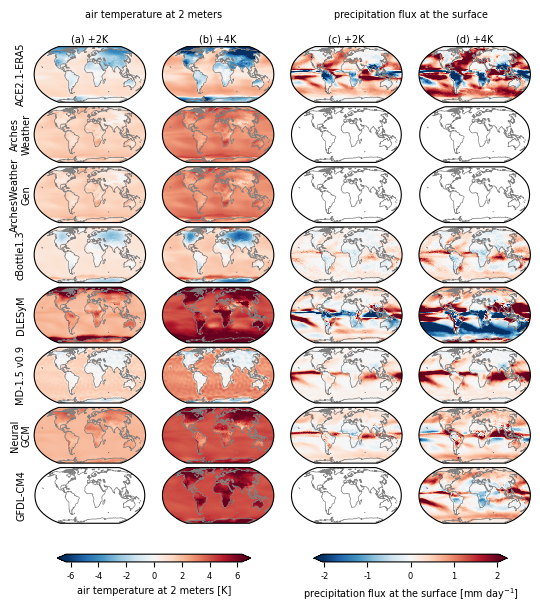

In [30]:
# Appendix Figure: perturbation response map at 2.8° resolution (NeuralGCM included)
plot_perturbation_response_map(
    combined_2p8deg_perturbed_sst_response_time_means,
    vars_to_plot=['tas', 'pr'],
    save_name='app_perturbation_response_map_2p8deg_tas_pr',
)